### Mushroom Hunting: Edible or Poisonous?

This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525). Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous one. The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like ``leaflets three, let it be'' for Poisonous Oak and Ivy.


Attribute Information:

1. cap-shape:
    - bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s

2. cap-surface:

   - fibrous=f, grooves=g, scaly=y, smooth=s

3. cap-color:

   - brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y

4. bruises?:

   - bruises=t, no=f

5. odor:

   - almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s

6. gill-attachment:

   - attached=a, descending=d, free=f, notched=n

7. gill-spacing:

   - close=c, crowded=w, distant=d

8. gill-size:

   - broad=b, narrow=n

9. gill-color:

    - black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y

10. stalk-shape:

    - enlarging=e, tapering=t

11. stalk-root:

    - bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?

12. stalk-surface-above-ring:

    - fibrous=f, scaly=y, silky=k, smooth=s

13. stalk-surface-below-ring:

    - fibrous=f, scaly=y, silky=k, smooth=s

14. stalk-color-above-ring:

    - brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y

15. stalk-color-below-ring:

    - brown=n ,buff=b ,cinnamon=c ,gray=g ,orange=o, pink=p, red=e, white=w, yellow=y

16. veil-type:

    - partial=p, universal=u

17. veil-color:

    - brown=n, orange=o, white=w, yellow=y

18. ring-number:

    - none=n, one=o, two=t

19. ring-type:

    - cobwebby=c, evanescent=e, flaring=f, large=l, none=n ,pendant=p, sheathing=s, zone=z

20. spore-print-color:

    - black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y

21. population:

     - abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y

22. habitat:

    - grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

#### 1) Importing Necessary Libraries:

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

import time

#### 2) Loading Data:

In [2]:
df = pd.read_csv('mushrooms.csv')

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [4]:
df.shape

(8124, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [7]:
df.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


- All the features are Categorical and Nominal in Nature.
- There are no missing values in the data.
- 'class' is our target variable.

In [8]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

#### 3) Preprocessing:

- As all the features are Categorical and Nominal in Nature, we will One Hot Encode all the features in
  one single Column Transformer.

In [19]:
preprocessor = ColumnTransformer([
    ('Encoder', OneHotEncoder(handle_unknown= 'ignore'), list(df.drop('class', axis= 1).columns))
])

#### 4) Train Test Split:

In [13]:
X = df.drop('class', axis= 1) #Features
y = df['class'] #Target

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6499, 22)
(1625, 22)
(6499,)
(1625,)


#### 5) Model Building and Evaluations:

##### 1) Model1: Simple AdaBoost Decision Stump:

              precision    recall  f1-score   support

           e       0.96      0.79      0.87       843
           p       0.81      0.97      0.88       782

    accuracy                           0.88      1625
   macro avg       0.89      0.88      0.88      1625
weighted avg       0.89      0.88      0.88      1625



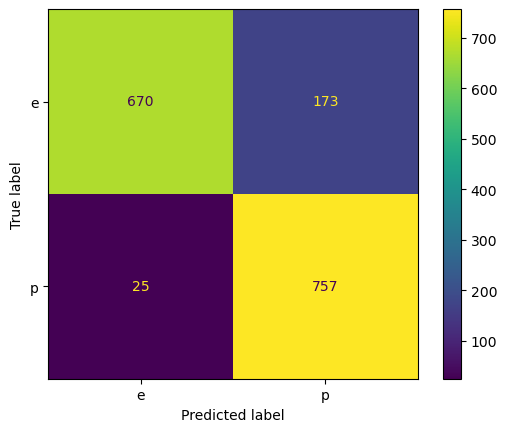

In [34]:
# Preprocessing and Model Pipe:
model1 = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', AdaBoostClassifier(n_estimators= 1))
])

# Fitting the Pipe:
model1.fit(X_train, y_train)

# Predictions using The Model:
y_pred1 = model1.predict(X_test)

# Classification Report:
print(classification_report(y_test, y_pred1))

# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(cm, display_labels= model1.classes_)
disp.plot()

- Even with one Decision Stump as estimator, AdaBoost gives 88% accuracy with quite high Precision and Recall
  scores for such a simple model.

In [36]:
# Feature Importance:

model1.named_steps['Model'].feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [38]:
# Checking which feature was regarded as the most important one by the model:

pd.DataFrame(index= preprocessor.get_feature_names_out(), 
            data= model1.named_steps['Model'].feature_importances_,
            columns= ['Feature Importance']).sort_values(by= 'Feature Importance', ascending= False)

,Feature Importance
Encoder__odor_n,1.0
Encoder__cap-shape_b,0.0
Encoder__ring-number_o,0.0
Encoder__veil-color_y,0.0
Encoder__veil-color_w,0.0
...,...
Encoder__gill-size_b,0.0
Encoder__gill-spacing_w,0.0
Encoder__gill-spacing_c,0.0
Encoder__gill-attachment_f,0.0


- 'odor' feature is used by model to split classes.

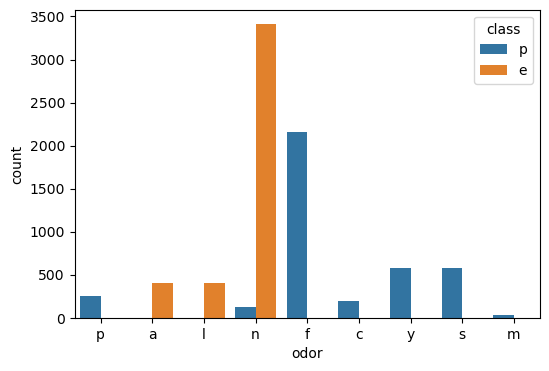

In [39]:
# Plotting Odor vs Classes:

plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'odor', hue= 'class')
plt.show()

- odor:
    - almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
 
Having No Odor seems to be one of the most important and distinguishing feature of Edible Mushroom.

##### 2) Building AdaBoost with Increasing Number of Estimators and Checking Accuracy:

In [40]:
# Looping Through AdaBoost Models with Increasing Number of Estimators:

accuracy_list = []

for num in range(1, 118): #Because we have 117 features in data after one hot encoding

    #Preprocessing and Model Pipe:
    model_pipe = Pipeline([
        ('Preprocessing', preprocessor),
        ('Model', AdaBoostClassifier(n_estimators= num))
    ])

    #Fitting The Pipe:
    model_pipe.fit(X_train, y_train)

    #Predictions using the Model:
    predictions= model_pipe.predict(X_test)

    #Storing Accuracy of The Current Model:
    accuracy_list.append(accuracy_score(y_test, predictions))

In [48]:
accuracy_list[:10]

[0.8781538461538462,
 0.8781538461538462,
 0.9230769230769231,
 0.9230769230769231,
 0.940923076923077,
 0.9556923076923077,
 0.9544615384615385,
 0.9735384615384616,
 0.940923076923077,
 0.9821538461538462]

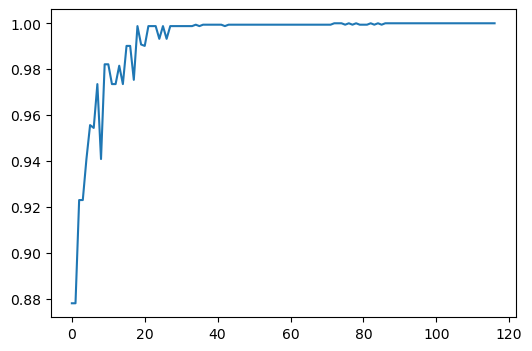

In [42]:
# Plotting Accuracy List:

plt.figure(figsize= (6,4))
sns.lineplot(data= accuracy_list)
plt.show()

- As seen from Accuracy List and Graph, Using 30 Estimators gives us best Accuracy.
- After 20 Estimators, Accuracy doesn't Change.
- So, we can create the final Model with 20 Estimators.

##### 3) Model2: AdaBoost with 30 Estimators:

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       843
           p       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



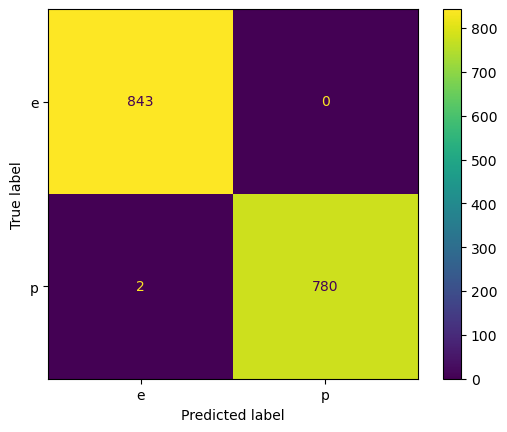

In [52]:
# Preprocessing and Model Pipe:
model2 = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', AdaBoostClassifier(n_estimators= 30))
])

# Fitting the Pipe:
model2.fit(X_train, y_train)

# Predictions using The Model:
y_pred2 = model2.predict(X_test)

# Classification Report:
print(classification_report(y_test, y_pred2))

# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(cm, display_labels= model2.classes_)
disp.plot()

In [54]:
# Checking feature importance :

feature_imp = pd.DataFrame(index= preprocessor.get_feature_names_out(), 
            data= model2.named_steps['Model'].feature_importances_,
            columns= ['Feature Importance']).sort_values(by= 'Feature Importance', ascending= False)

In [55]:
feature_imp[feature_imp['Feature Importance'] > 0]

,Feature Importance
Encoder__odor_n,0.169098
Encoder__odor_a,0.166315
Encoder__odor_l,0.149943
Encoder__spore-print-color_r,0.145113
Encoder__odor_f,0.084322
Encoder__stalk-surface-above-ring_k,0.061139
Encoder__population_v,0.051950
Encoder__gill-size_b,0.040220
Encoder__habitat_d,0.035719
Encoder__population_c,0.035423


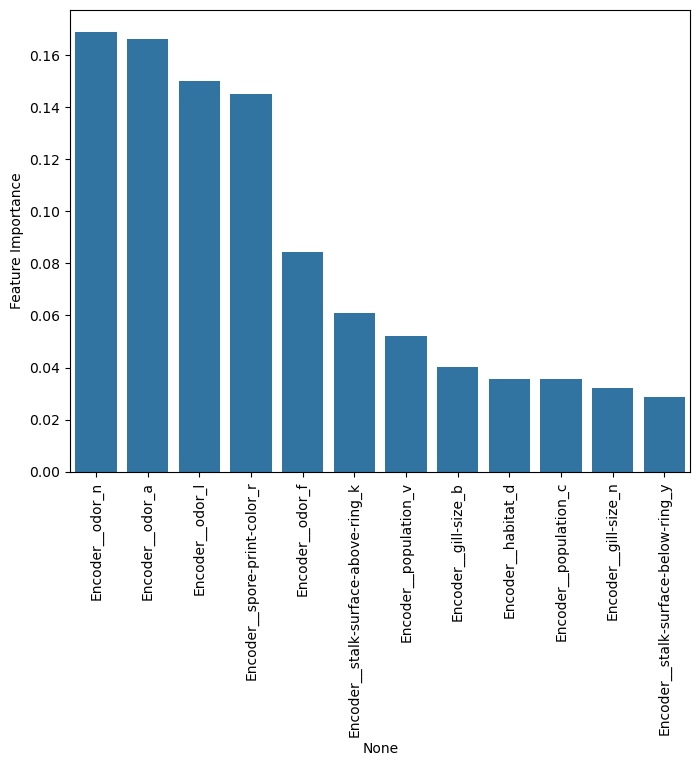

In [56]:
# Plotting Important Features:

plt.figure(figsize=(8,6), dpi= 100)
sns.barplot(data= feature_imp[feature_imp["Feature Importance"] > 0],
           x= feature_imp[feature_imp["Feature Importance"] > 0].index,
           y= feature_imp[feature_imp["Feature Importance"] > 0]["Feature Importance"])

plt.xticks(rotation= 90)
plt.show()